Model yang Diuji
Berdasarkan hasil backward elimination dari tahap sebelumnya, model final yang akan kita uji asumsinya adalah:

**P1 = β₀ + β₁(UHH) + β₂(RLS) + ε**

dimana:

**Y (Variabel Dependen):** P1 (Indeks Kedalaman Kemiskinan)

**X (Variabel Independen):** UHH (Umur Harapan Hidup) dan RLS (Rata-rata Lama Sekolah)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.regressionplots import influence_plot
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"D:/TUGAS KULIAH/Semester 3/Pemodelan dan Simulasi/dataset_final_2021-2023.csv")

In [ ]:
df_train = df[df["Tahun"].isin([2021, 2022])].copy()
df_test = df[df["Tahun"] == 2023].copy()

In [ ]:
X_cols_final = ["UHH", "RLS"]
y_train = df_train["P1"]

In [ ]:
# Bangun model OLS final menggunakan data training
X_train_final = sm.add_constant(df_train[X_cols_final])
model_final = sm.OLS(y_train, X_train_final).fit()

In [8]:
# Dapatkan residual dan nilai prediksi (fitted values) dari model training
residuals = model_final.resid
fitted = model_final.fittedvalues

In [9]:
print("Model Final (dari data training 2021-2022) untuk Uji Asumsi:")
print(model_final.summary())

Model Final (dari data training 2021-2022) untuk Uji Asumsi:
                            OLS Regression Results                            
Dep. Variable:                     P1   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     24.28
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           1.17e-08
Time:                        13:11:29   Log-Likelihood:                -55.107
No. Observations:                  70   AIC:                             116.2
Df Residuals:                      67   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

## **Uji Asusmsi 1: Normalitas Residual**

Asumsi ini menyatakan bahwa residual (selisih antara nilai aktual dan nilai prediksi) harus berdistribusi normal. Distribusi normal yang simetris di sekitar nol menunjukkan bahwa model tidak memiliki bias sistematis dalam prediksinya.

**Hipotesis**

**H₀:** Residual berdistribusi normal.

**H₁:** Residual tidak berdistribusi normal.

#### **Metode Pengujian**

**Visualisasi:**

Q-Q Plot: Membandingkan kuantil residual dengan kuantil distribusi normal. Jika titik-titik mengikuti garis lurus, asumsi normalitas terpenuhi.
Histogram: Menunjukkan bentuk distribusi residual secara visual.

**Uji Statistik:**

Uji Shapiro-Wilk: Uji yang paling umum digunakan untuk normalitas.
Uji Anderson-Darling: Memberikan bobot lebih pada ekor distribusi.

=== UJI NORMALITAS RESIDUAL ===
----------------------------------------


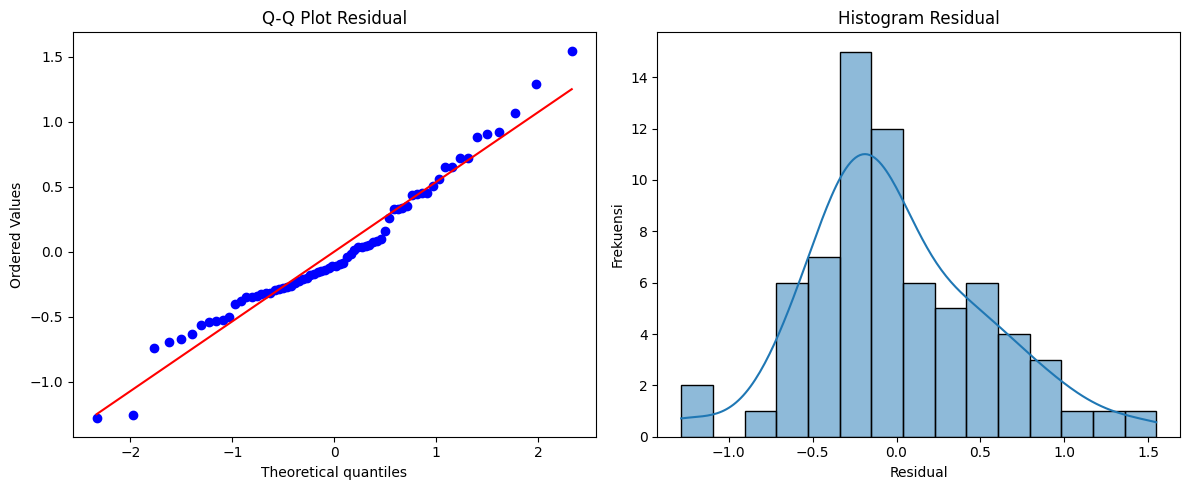

Hasil Uji Shapiro-Wilk:
  Statistik: 0.9678
  P-value: 0.0680
  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)

Hasil Uji Anderson-Darling:
  Statistik: 0.9478
  P-value: 0.0156
  Kesimpulan: Residual tidak terdistribusi normal (tolak H0)


In [ ]:
print("=== UJI NORMALITAS RESIDUAL ===")
print("-" * 40)

# Visualisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot Residual')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=15)
plt.title('Histogram Residual')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Uji Statistik Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Hasil Uji Shapiro-Wilk:")
print(f"  Statistik: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)")
else:
    print("  Kesimpulan: Residual tidak terdistribusi normal (tolak H0)")

# Uji Statistik Anderson-Darling
ad_stat, ad_pvalue = normal_ad(residuals)
print(f"\nHasil Uji Anderson-Darling:")
print(f"  Statistik: {ad_stat:.4f}")
print(f"  P-value: {ad_pvalue:.4f}")
if ad_pvalue > 0.05:
    print("  Kesimpulan: Residual terdistribusi normal (gagal tolak H0)")
else:
    print("  Kesimpulan: Residual tidak terdistribusi normal (tolak H0)")

## **Uji Asumsi 2: Homoskedastisitas**

Asumsi ini menyatakan bahwa varians (sebaran) residual harus konstan untuk semua nilai prediksi. Jika varians tidak konstan (heteroskedastisitas), maka estimasi koefisien regresi tidak lagi efisien, dan uji signifikansi (uji t dan F) menjadi tidak dapat dipercaya.

**Hipotesis**

**H₀:** Terjadi homoskedastisitas (varians konstan).

**H₁:** Terjadi heteroskedastisitas (varians tidak konstan).

#### **Metode Pengujian**

**Visualisasi:**

Scatter Plot Residual vs. Nilai Prediksi: Plot residual terhadap nilai yang diprediksi oleh model. Jika titik-titik menyebar secara acak tanpa membentuk pola (misalnya corong), asumsi homoskedastisitas terpenuhi.

**Uji Statistik:**

Uji Breusch-Pagan: Uji formal untuk mendeteksi heteroskedastisitas.


=== UJI HOMOSKEDASTISITAS ===
----------------------------------------


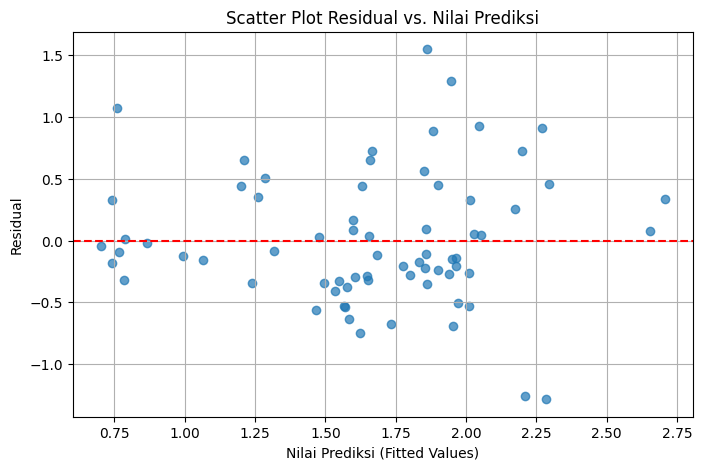

Hasil Uji Breusch-Pagan:
  LM Statistic: 6.0106
  LM-Test p-value: 0.0495
  F-Statistic: 3.1467
  F-Test p-value: 0.0494
  Kesimpulan: Terjadi heteroskedastisitas (tolak H0)


In [13]:
print("\n=== UJI HOMOSKEDASTISITAS ===")
print("-" * 40)

# Visualisasi
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Nilai Prediksi (Fitted Values)')
plt.ylabel('Residual')
plt.title('Scatter Plot Residual vs. Nilai Prediksi')
plt.grid(True)
plt.show()

# Uji Breusch-Pagan
# exog adalah matriks variabel independen dari model
bp_test = het_breuschpagan(residuals, model_final.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("Hasil Uji Breusch-Pagan:")
for label, value in zip(labels, bp_test):
    print(f"  {label}: {value:.4f}")

if bp_test[1] > 0.05:
    print("  Kesimpulan: Terjadi homoskedastisitas (gagal tolak H0)")
else:
    print("  Kesimpulan: Terjadi heteroskedastisitas (tolak H0)")

## **Uji asumsi 3: Tidak Ada Autokorelasi**

Asumsi ini menyatakan bahwa residual (selisih antara nilai aktual dan nilai prediksi) harus berdistribusi normal. Distribusi normal yang simetris di sekitar nol menunjukkan bahwa model tidak memiliki bias sistematis dalam prediksinya.

**Hipotesis**

**H₀:** Tidak ada autokorelasi.

**H₁:** Ada autokorelasi.

#### **Metode Pengujian**

Uji Durbin-Watson: Uji statistik yang paling umum digunakan untuk mendeteksi autokorelasi orde satu.

Nilai DW mendekati 2: Tidak ada autokorelasi.

Nilai DW < 2: Ada indikasi autokorelasi positif.

Nilai DW > 2: Ada indikasi autokorelasi negatif.

In [14]:
print("\n=== UJI AUTOKORELASI ===")
print("-" * 40)

# Uji Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Hasil Uji Durbin-Watson:")
print(f"  Statistik: {dw_stat:.4f}")

if 1.5 < dw_stat < 2.5:
    print("  Kesimpulan: Tidak ada autokorelasi (statistik mendekati 2)")
elif dw_stat < 1.5:
    print("  Kesimpulan: Ada indikasi autokorelasi positif")
else:
    print("  Kesimpulan: Ada indikasi autokorelasi negatif")


=== UJI AUTOKORELASI ===
----------------------------------------
Hasil Uji Durbin-Watson:
  Statistik: 2.1232
  Kesimpulan: Tidak ada autokorelasi (statistik mendekati 2)


## **Uji asumsi 4: Linearitas**

Asumsi ini menyatakan bahwa hubungan antara variabel dependen (P1) dan masing-masing variabel independen (UHH, RLS) adalah linear. Jika hubungannya tidak linear, model linier tidak akan mampu menangkap pola data dengan baik.

**Hipotesis**

**H₀:** Model bersifat linear.

**H₁:** Model tidak linear.

#### **Metode Pengujian**

**Visualisasi:**

Scatter Plot: Membuat plot antara P1 dan masing-masing variabel independen (UHH dan RLS) beserta garis regresinya.

**Uji Statistik:**

Uji Rainbow: Menguji apakah model linear lebih baik daripada model non-linear.


=== UJI LINEARITAS ===
----------------------------------------


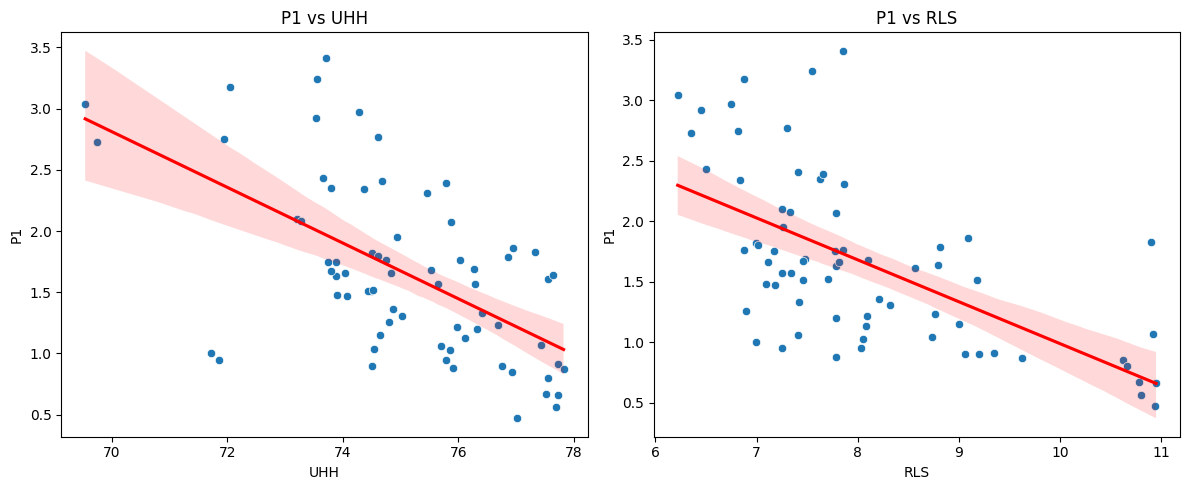

Hasil Uji Rainbow:
  Statistik: 0.8231
  P-value: 0.7137
  Kesimpulan: Model linear (gagal tolak H0)


In [15]:
print("\n=== UJI LINEARITAS ===")
print("-" * 40)

# Visualisasi
plt.figure(figsize=(12, 5))
for i, col in enumerate(X_cols_final):
    plt.subplot(1, 2, i+1)
    sns.scatterplot(x=df_train[col], y=y_train)
    sns.regplot(x=df_train[col], y=y_train, scatter=False, color='red', line_kws={'color':'red'})
    plt.title(f'P1 vs {col}')
plt.tight_layout()
plt.show()

# Uji Rainbow
rainbow_stat, rainbow_p = linear_rainbow(model_final)
print("Hasil Uji Rainbow:")
print(f"  Statistik: {rainbow_stat:.4f}")
print(f"  P-value: {rainbow_p:.4f}")
if rainbow_p > 0.05:
    print("  Kesimpulan: Model linear (gagal tolak H0)")
else:
    print("  Kesimpulan: Model tidak linear (tolak H0)")

## **Uji Asumsi 5: Tidak Ada Multikolinearitas**

Asumsi ini menyatakan bahwa tidak ada korelasi yang tinggi di antara variabel-variabel independen. Meskipun model final kita hanya memiliki dua variabel (UHH dan RLS), penting untuk memeriksanya. Multikolinearitas yang tinggi dapat membuat estimasi koefisien menjadi tidak stabil dan sulit diinterpretasikan.

#### **Metode Pengujian**

Variance Inflation Factor (VIF): Mengukur seberapa besar varians koefisien suatu variabel "membengkak" karena adanya korelasi dengan variabel independen lainnya.

VIF < 4: Tidak ada masalah multikolinearitas.

4 ≤ VIF < 10: Ada indikasi multikolinearitas.

VIF ≥ 10: Multikolinearitas serius.

In [16]:
print("\n=== UJI MULTIKOLINEARITAS (VIF) ===")
print("-" * 40)

# Hitung VIF untuk variabel independen di model final (menggunakan data training)
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_cols_final
vif_data["VIF"] = [variance_inflation_factor(df_train[X_cols_final].values, i)
                   for i in range(len(X_cols_final))]

print(vif_data)

print("\nInterpretasi VIF:")
for _, row in vif_data.iterrows():
    var = row["Variabel"]
    vif = row["VIF"]
    if vif < 4:
        print(f"  {var}: Tidak ada multikolinearitas (VIF < 4)")
    elif 4 <= vif < 10:
        print(f"  {var}: Ada indikasi multikolinearitas (4 ≤ VIF < 10)")
    else:
        print(f"  {var}: Multikolinearitas tinggi (VIF ≥ 10)")


=== UJI MULTIKOLINEARITAS (VIF) ===
----------------------------------------
  Variabel        VIF
0      UHH  54.066808
1      RLS  54.066808

Interpretasi VIF:
  UHH: Multikolinearitas tinggi (VIF ≥ 10)
  RLS: Multikolinearitas tinggi (VIF ≥ 10)


## **Deteksi outlier dan influential points**

Selain asumsi klasik, penting juga untuk mengidentifikasi pengamatan yang tidak biasa atau memiliki pengaruh yang sangat besar terhadap model (influential points).

Outlier: Pengamatan yang nilainya jauh berbeda dari pengamatan lainnya.

Influential Point: Pengamatan yang, jika dihapus, akan secara signifikan mengubah hasil estimasi model.

#### **Metode Pengujian**
1. Standardized Residual: Mengidentifikasi outlier. Nilai yang lebih besar dari 2 atau kurang dari -2 sering dianggap sebagai outlier.
2. Leverage: Mengukur seberapa jauh nilai variabel independen suatu pengamatan dari nilai rata-ratanya.
3. Cook's Distance: Menggabungkan informasi dari leverage dan residual untuk mengukur pengaruh total suatu pengamatan.


=== DETEKSI OUTLIER DAN INFLUENTIAL POINTS ===
----------------------------------------


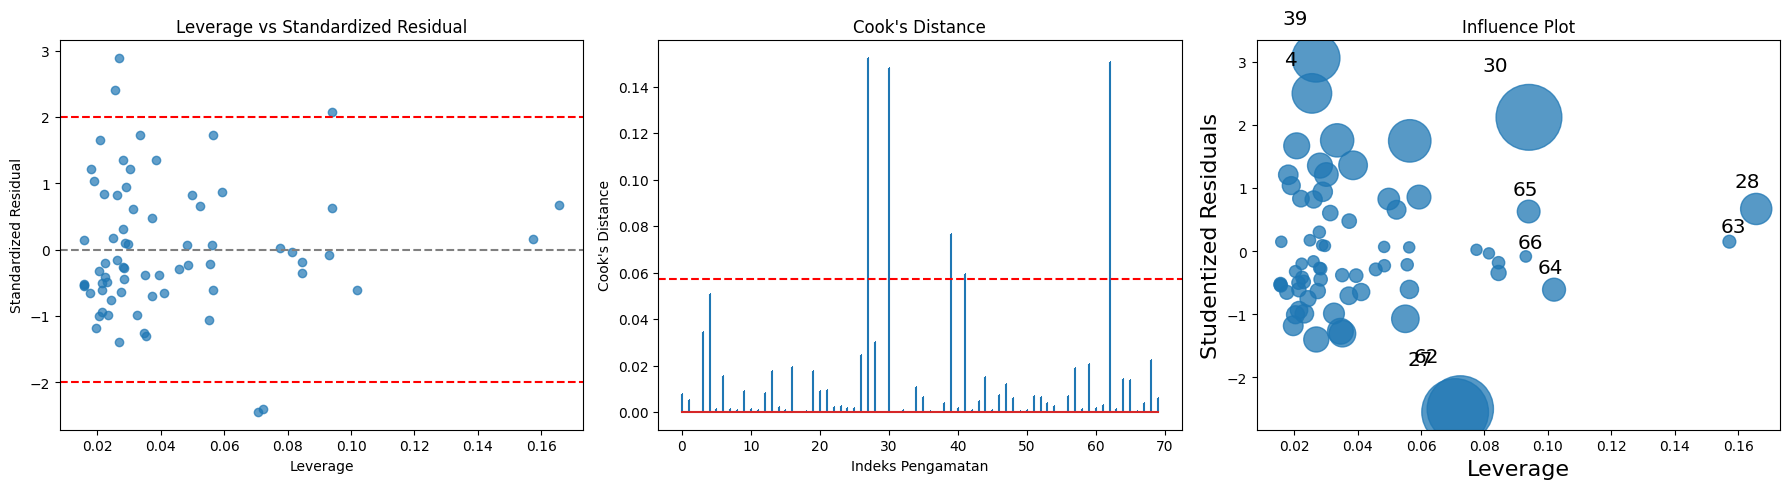

Jumlah outlier (|Std. Residual| > 2): 5
Indeks outlier: [ 4 27 30 39 62]


,Wilayah,Tahun,P1,UHH,RLS
4,Kabupaten Kebumen,2021,3.24,73.55,7.55
27,Kabupaten Tegal,2021,1.00,71.72,6.99
30,Kota Surakarta,2021,1.83,77.32,10.90
39,Kabupaten Kebumen,2022,3.41,73.70,7.85
62,Kabupaten Tegal,2022,0.95,71.85,7.25



Jumlah influential points (Cook's D > 0.0571): 5
Indeks influential points: [27 30 39 41 62]


,Wilayah,Tahun,P1,UHH,RLS
27,Kabupaten Tegal,2021,1.00,71.72,6.99
30,Kota Surakarta,2021,1.83,77.32,10.90
39,Kabupaten Kebumen,2022,3.41,73.70,7.85
41,Kabupaten Wonosobo,2022,3.18,72.05,6.88
62,Kabupaten Tegal,2022,0.95,71.85,7.25


In [17]:
print("\n=== DETEKSI OUTLIER DAN INFLUENTIAL POINTS ===")
print("-" * 40)

# Hitung metrik diagnostik
influence = model_final.get_influence()
leverage = influence.hat_matrix_diag
standardized_residual = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]

# Visualisasi
plt.figure(figsize=(18, 5))

# Plot 1: Leverage vs Standardized Residual
plt.subplot(1, 3, 1)
plt.scatter(leverage, standardized_residual, alpha=0.7)
plt.axhline(y=0, color='grey', linestyle='dashed')
plt.axhline(y=2, color='red', linestyle='dashed')
plt.axhline(y=-2, color='red', linestyle='dashed')
plt.xlabel('Leverage')
plt.ylabel('Standardized Residual')
plt.title('Leverage vs Standardized Residual')

# Plot 2: Cook's Distance
plt.subplot(1, 3, 2)
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=4/len(df_train), color='red', linestyle='dashed')
plt.xlabel('Indeks Pengamatan')
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")

# Plot 3: Influence Plot
plt.subplot(1, 3, 3)
influence_plot(model_final, ax=plt.gca())
plt.title('Influence Plot')

plt.tight_layout()
plt.show()

# Identifikasi dan tampilkan data outlier
outlier_threshold = 2
outlier_indices = np.where(np.abs(standardized_residual) > outlier_threshold)[0]
print(f"Jumlah outlier (|Std. Residual| > {outlier_threshold}): {len(outlier_indices)}")
if len(outlier_indices) > 0:
    print("Indeks outlier:", outlier_indices)
    display(df_train.iloc[outlier_indices][['Wilayah', 'Tahun', 'P1', 'UHH', 'RLS']])

# Identifikasi dan tampilkan influential points
cook_threshold = 4/len(df_train)
influential_indices = np.where(cooks_d > cook_threshold)[0]
print(f"\nJumlah influential points (Cook's D > {cook_threshold:.4f}): {len(influential_indices)}")
if len(influential_indices) > 0:
    print("Indeks influential points:", influential_indices)
    display(df_train.iloc[influential_indices][['Wilayah', 'Tahun', 'P1', 'UHH', 'RLS']])